In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para que los gráficos se vean dentro del notebook
%matplotlib inline

# Estilo básico
plt.style.use("ggplot")
sns.set()

# Cargando datos
people = pd.read_csv("C:/Users/jarie/OneDrive/Desktop/data baseball project/bateadores_rd/data/People.csv")
batting = pd.read_csv("C:/Users/jarie/OneDrive/Desktop/data baseball project/bateadores_rd/data/Batting.csv")


people.head(), batting.head()

# Filtra jugadores dominicanos
dominicanos = people[
    (people["birthCountry"] == "D.R.") |
    (people["birthCountry"] == "Dominican Republic")
].copy()

dominicanos[["playerID", "nameFirst", "nameLast", "birthCountry"]].head()
print("Jugadores dominicanos:", dominicanos.shape[0])

# Une dominicanos con sus batting stats 
df = batting.merge(
    dominicanos[["playerID", "nameFirst", "nameLast", "birthCountry"]],
    on="playerID",
    how="inner"
)

df.head()
print(df.shape)

# Mínimo 100 turnos al bate
df = df[df["AB"] >= 100].copy()

# Sencillos
df["1B"] = df["H"] - (df["2B"] + df["3B"] + df["HR"])

# Evitar divisiones entre cero
df["OBP"] = (df["H"] + df["BB"] + df["HBP"]) / (
    df["AB"] + df["BB"] + df["HBP"] + df["SF"]
)
df["SLG"] = (df["1B"] + 2*df["2B"] + 3*df["3B"] + 4*df["HR"]) / df["AB"]

df["AVG"] = df["H"] / df["AB"]
df["OPS"] = df["OBP"] + df["SLG"]

# Limpiamos infinitos y cosas raras
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(subset=["OBP", "SLG", "OPS", "AVG"], inplace=True)

df[["nameFirst", "nameLast", "yearID", "AB", "H", "AVG", "OBP", "SLG", "OPS"]].head()

# Top 10 jugadores con mas HR desde el año 1970
df_2000 = df[df["yearID"] >= 1970].copy()

top_hr = (
    df_2000.groupby(["playerID", "nameFirst", "nameLast"], as_index=False)
    .agg({"HR": "sum"})
    .sort_values("HR", ascending=False)
    .head(10)
)

top_hr

#Gráfico
plt.figure(figsize=(10, 6))
plt.barh(
    top_hr["nameFirst"] + " " + top_hr["nameLast"],
    top_hr["HR"]
)
plt.xlabel("HR totales (desde 1970)")
plt.title("Top 10 bateadores dominicanos por HR (1970)")
plt.gca().invert_yaxis()  # Para que el mayor quede arriba
plt.tight_layout()
plt.show()







Jugadores dominicanos: 918
(5294, 27)


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

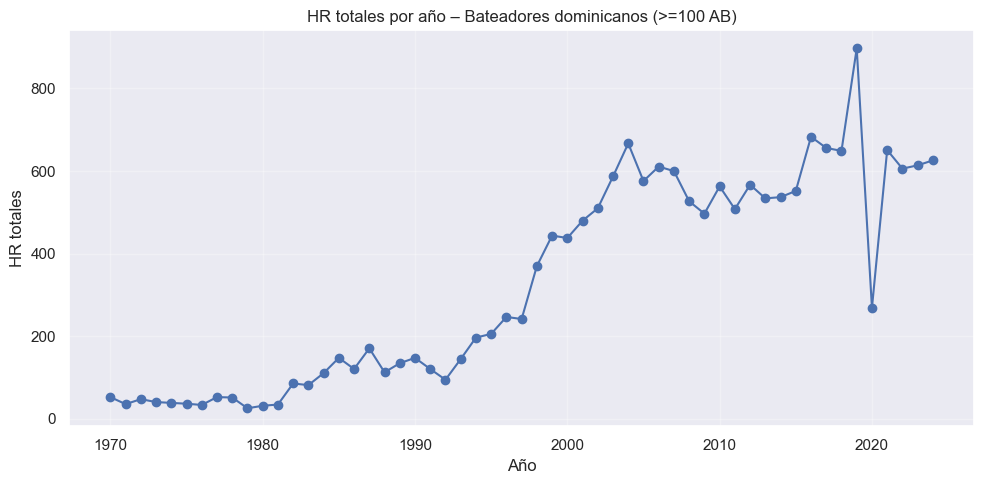

In [13]:
hr_por_anio = (
    df_2000.groupby("yearID", as_index=False)
    .agg({"HR": "sum"})
)

plt.figure(figsize=(10, 5))
plt.plot(hr_por_anio["yearID"], hr_por_anio["HR"], marker="o")
plt.title("HR totales por año – Bateadores dominicanos (>=100 AB)")
plt.xlabel("Año")
plt.ylabel("HR totales")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
df_2000[df_2000["nameLast"] == "Soto"][["nameFirst", "nameLast"]].drop_duplicates()

soto = df_2000[
    (df_2000["nameFirst"] == "Juan") &
    (df_2000["nameLast"] == "Soto")
].copy()

soto[["yearID", "teamID", "AB", "H", "HR", "AVG", "OBP", "SLG", "OPS"]]


,yearID,teamID,AB,H,HR,AVG,OBP,SLG,OPS
4758,2018,WAS,414,121,22,0.292271,0.405680,0.516908,0.922588
4759,2019,WAS,542,153,34,0.282288,0.400607,0.547970,0.948577
4760,2020,WAS,154,54,13,0.350649,0.489796,0.694805,1.184601
4761,2021,WAS,502,157,29,0.312749,0.464832,0.533865,0.998696
4762,2022,WAS,342,84,21,0.245614,0.408257,0.485380,0.893637
4763,2022,SDN,182,43,6,0.236264,0.387665,0.390110,0.777775
4764,2023,SDN,568,156,35,0.274648,0.410184,0.519366,0.929550
4765,2024,NYA,576,166,41,0.288194,0.419355,0.569444,0.988799


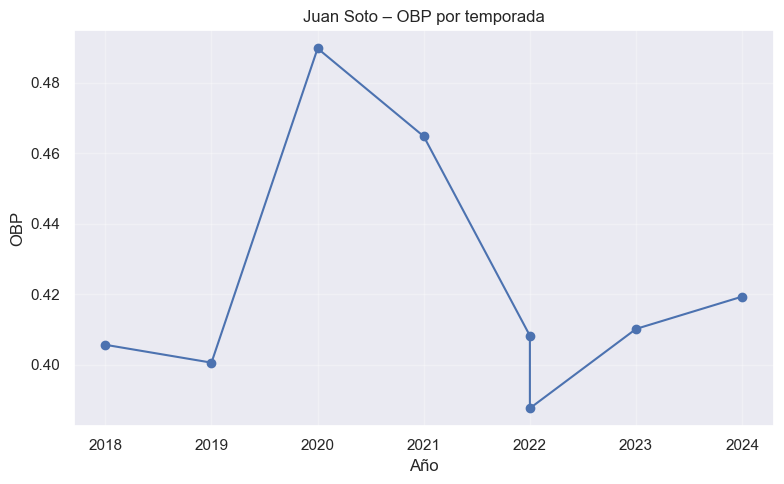

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(soto["yearID"], soto["OBP"], marker="o")
plt.title("Juan Soto – OBP por temporada")
plt.xlabel("Año")
plt.ylabel("OBP")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [25]:
#Dominicanos con mas Triples desde el 2020
df_2020 = df[df["yearID"] >= 2020].copy()

top_3b = (
    df_2020.groupby(["nameFirst", "nameLast"], as_index=False)
    .agg({"3B": "sum"})
    .sort_values("3B", ascending=False)
    .head(10)
)

top_3b


,nameFirst,nameLast,3B
2,Amed,Rosario,27
39,Jose,Ramirez,18
13,Elly,De La Cruz,17
47,Ketel,Marte,15
80,Wander,Franco,14
76,Starling,Marte,13
36,Jorge,Mateo,12
48,Leody,Taveras,11
7,Christopher,Morel,10
43,Juan,Soto,9


C:\Users\jarie\AppData\Local\Temp\ipykernel_10428\739124791.py:21: UserWarning: Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\jarie\AppData\Local\Temp\ipykernel_10428\739124791.py:21: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\jarie\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127465 (\N{REGIONAL INDICATOR SYMBOL LETTER D}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\jarie\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127476 (\N{REGIONAL INDICATOR SYMBOL LETTER O}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


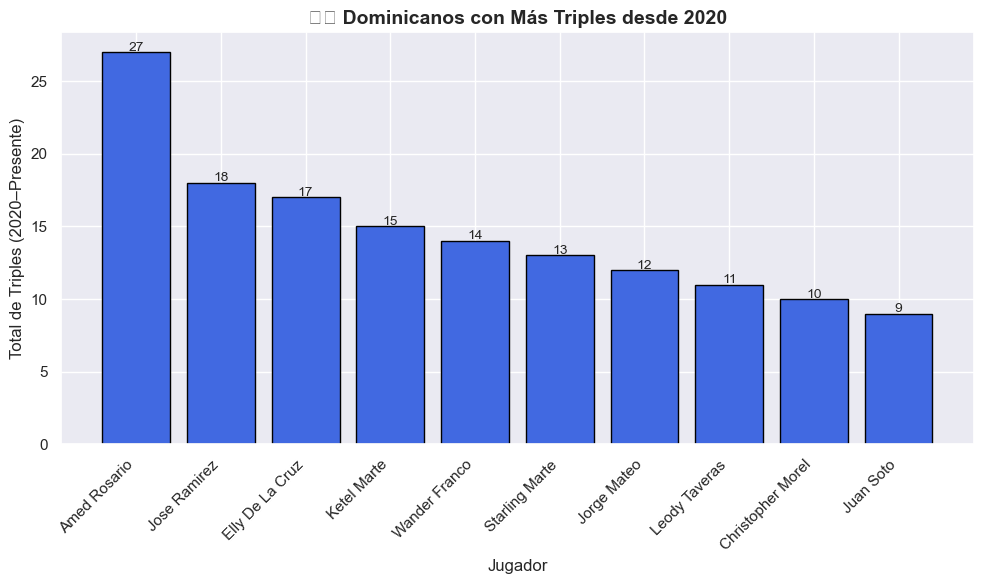

In [26]:
import matplotlib.pyplot as plt

# Crear columna con nombre completo
top_3b["Nombre"] = top_3b["nameFirst"] + " " + top_3b["nameLast"]

plt.figure(figsize=(10, 6))

# Gráfico de barras vertical
plt.bar(top_3b["Nombre"], top_3b["3B"], color="royalblue", edgecolor="black")

# Títulos y etiquetas
plt.title("🇩🇴 Dominicanos con Más Triples desde 2020", fontsize=14, fontweight="bold")
plt.xlabel("Jugador")
plt.ylabel("Total de Triples (2020–Presente)")
plt.xticks(rotation=45, ha="right")   # Rotar nombres para claridad

# Añadir valores encima de cada barra
for i, v in enumerate(top_3b["3B"]):
    plt.text(i, v + 0.1, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()
